# 🏆 MLOps Model Tournament Pipeline

**Project 1 of 10 — MLOps Portfolio Series**  
**Author:** Jumma Mohammad Teli | Birmingham, UK  
**Dataset:** UCI Bank Marketing (41,188 rows, real data)  
**Goal:** Automatically train 5 models, select the champion by AUC, and register to MLflow Model Registry

---

## Notebook Structure
1. Setup & Imports
2. Data Loading & Exploration (EDA)
3. Feature Engineering & Preprocessing
4. Model Tournament (MLflow Tracked)
5. Results & Champion Selection
6. Visualisations
7. MLflow Model Registry
8. Key Takeaways

## 1. Setup & Imports

In [1]:
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

# Allow MLflow file-based tracking
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, roc_curve, classification_report
)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

RANDOM_STATE = 42
print('✅ All imports successful')
print(f'MLflow version: {mlflow.__version__}')

✅ All imports successful
MLflow version: 3.13.0


## 2. Data Loading & Exploration (EDA)

In [2]:
# Load dataset — UCI Bank Marketing (real data)
DATA_PATH = '../data/bank-additional-full.csv'

df = pd.read_csv(DATA_PATH, sep=';')
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head()

Dataset shape: (41188, 21)
Rows: 41,188 | Columns: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Data types and missing values
print('=== DATA TYPES ===')
print(df.dtypes)
print(f'\n=== MISSING VALUES ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

=== DATA TYPES ===
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

=== MISSING VALUES ===
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed      

=== TARGET DISTRIBUTION ===
  no: 36,548 (88.7%)
  yes: 4,640 (11.3%)


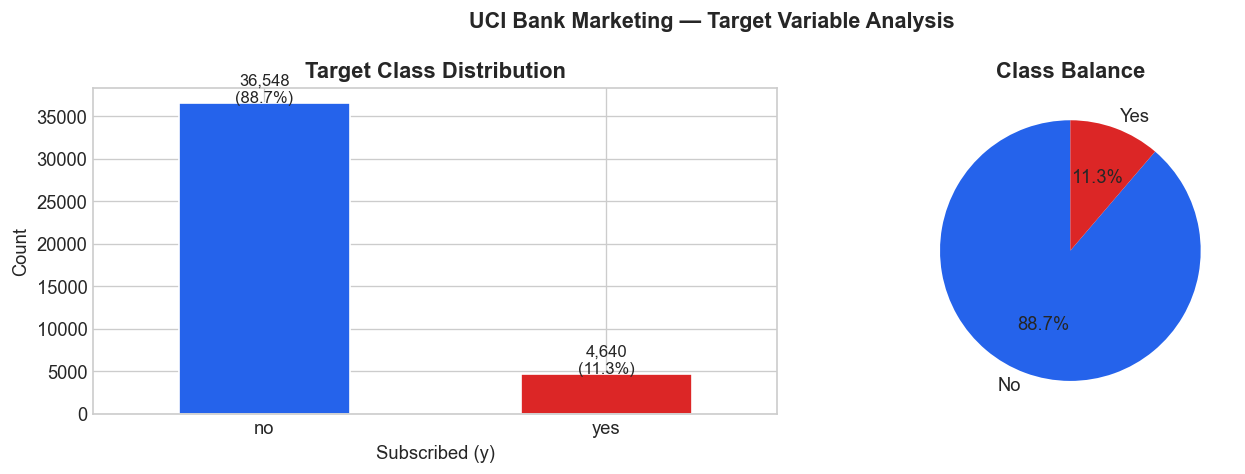

⚠️  Class imbalance: ~11.3% positive — all models use class_weight=balanced


In [4]:
# Target distribution
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print('=== TARGET DISTRIBUTION ===')
for val in target_counts.index:
    print(f'  {val}: {target_counts[val]:,} ({target_pct[val]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2563EB', '#DC2626']
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 100, f'{v:,}\n({target_pct.iloc[i]:.1f}%)', 
                 ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_counts, labels=['No', 'Yes'], colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Balance', fontweight='bold')

plt.suptitle('UCI Bank Marketing — Target Variable Analysis', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('⚠️  Class imbalance: ~11.3% positive — all models use class_weight=balanced')

In [5]:
# Numeric feature distributions
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f'Numeric features: {numeric_cols}')
df[numeric_cols].describe().round(2)

Numeric features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


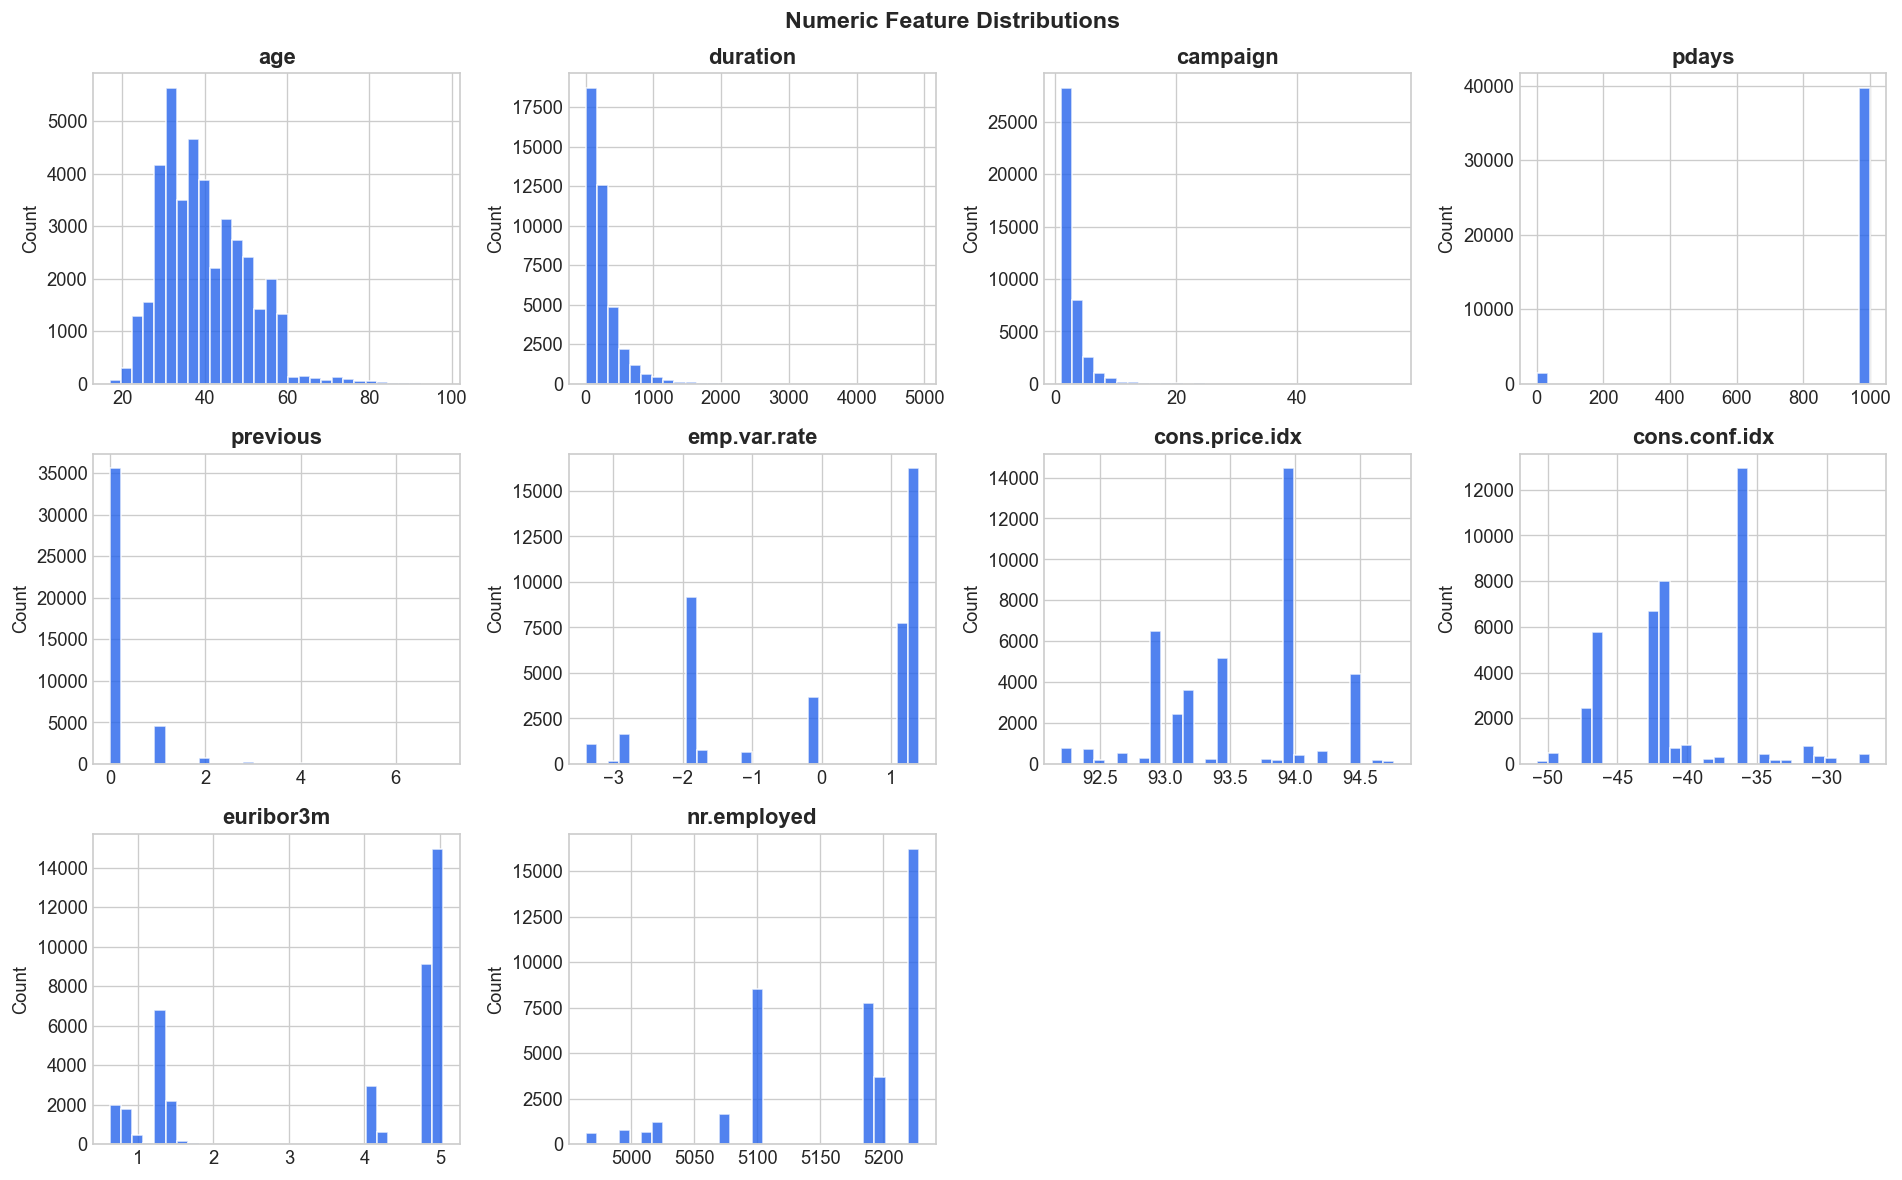

In [6]:
# Numeric feature histograms
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:12]):
    df[col].hist(ax=axes[i], bins=30, color='#2563EB', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


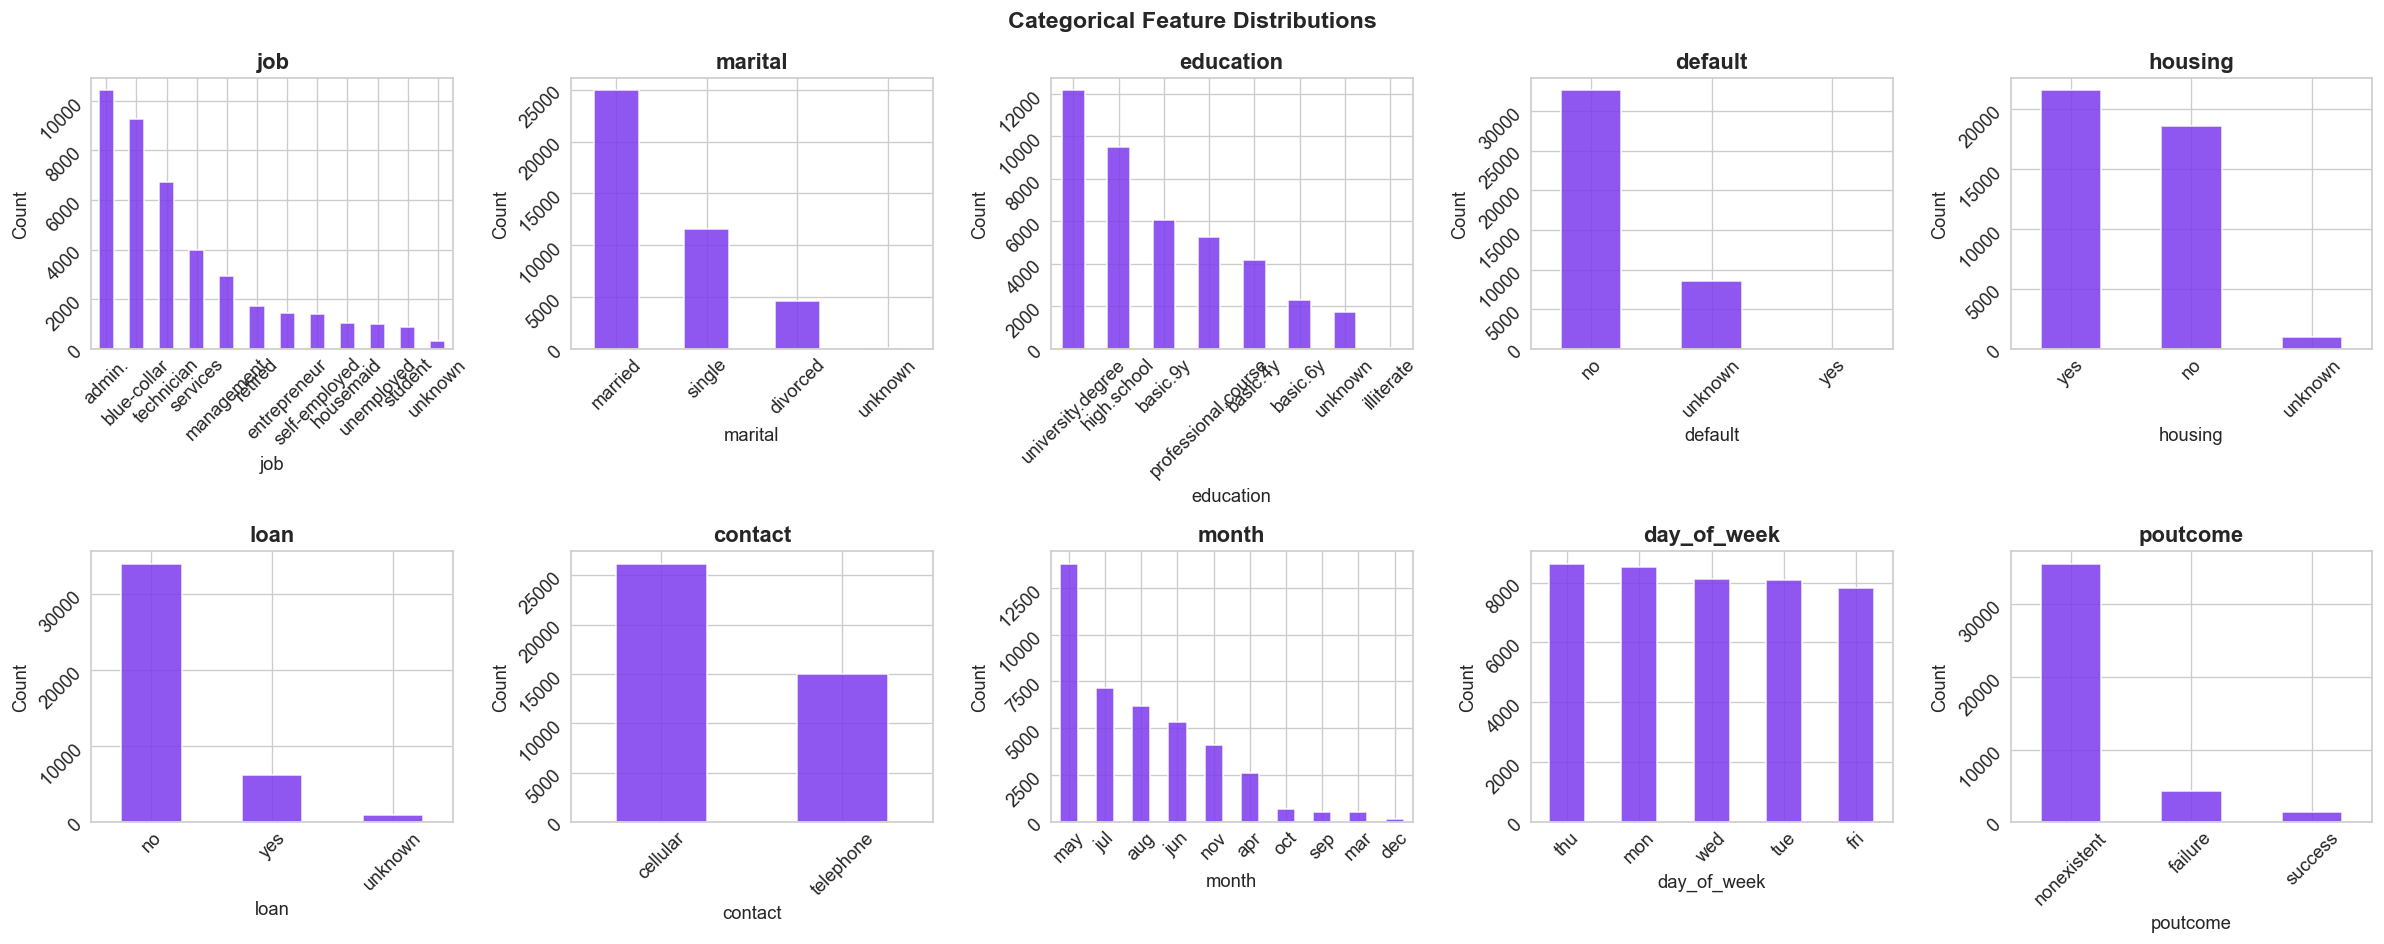

In [7]:
# Categorical feature analysis
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'y']
print(f'Categorical features: {cat_cols}')

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:10]):
    vc = df[col].value_counts()
    vc.plot(kind='bar', ax=axes[i], color='#7C3AED', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].tick_params(rotation=45)
    axes[i].set_ylabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

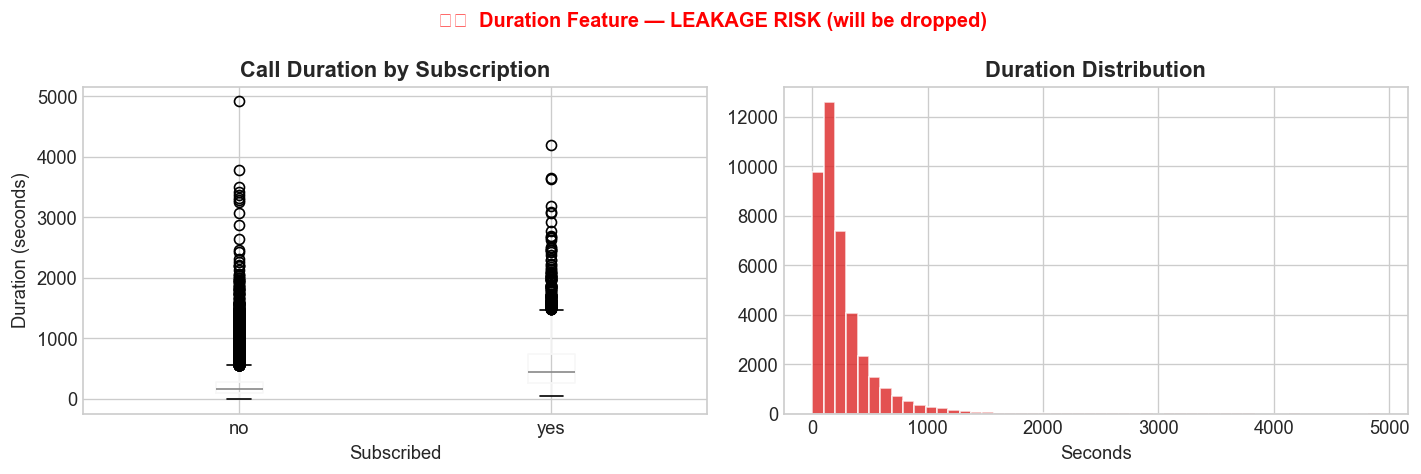


⚠️  duration is dropped: unknown before call is made → data leakage
Correlation with target (encoded): 0.405


In [8]:
# Duration feature — leakage analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Duration by target
df.boxplot(column='duration', by='y', ax=axes[0])
axes[0].set_title('Call Duration by Subscription', fontweight='bold')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Duration (seconds)')

# Duration distribution
df['duration'].hist(bins=50, ax=axes[1], color='#DC2626', edgecolor='white', alpha=0.8)
axes[1].set_title('Duration Distribution', fontweight='bold')
axes[1].set_xlabel('Seconds')

plt.suptitle('⚠️  Duration Feature — LEAKAGE RISK (will be dropped)', 
             fontsize=12, fontweight='bold', color='red')
plt.tight_layout()
plt.show()
print('\n⚠️  duration is dropped: unknown before call is made → data leakage')
print(f'Correlation with target (encoded): {df["duration"].corr(pd.get_dummies(df["y"])["yes"]):.3f}')

## 3. Feature Engineering & Preprocessing

In [9]:
def preprocess(df, drop_duration=True):
    df = df.copy()
    
    # Encode target
    df['y'] = (df['y'] == 'yes').astype(int)
    
    # Drop leakage feature
    if drop_duration:
        df = df.drop(columns=['duration'])
        print('⚠️  Dropped duration (leakage risk)')
    
    # Encode categoricals
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))
    
    return df

df_clean = preprocess(df, drop_duration=True)

X = df_clean.drop(columns=['y'])
y = df_clean['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {list(X.columns)}')
print(f'Class balance (train): {y_train.mean():.1%} positive')

⚠️  Dropped duration (leakage risk)

Train: (32950, 19) | Test: (8238, 19)
Features: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Class balance (train): 11.3% positive


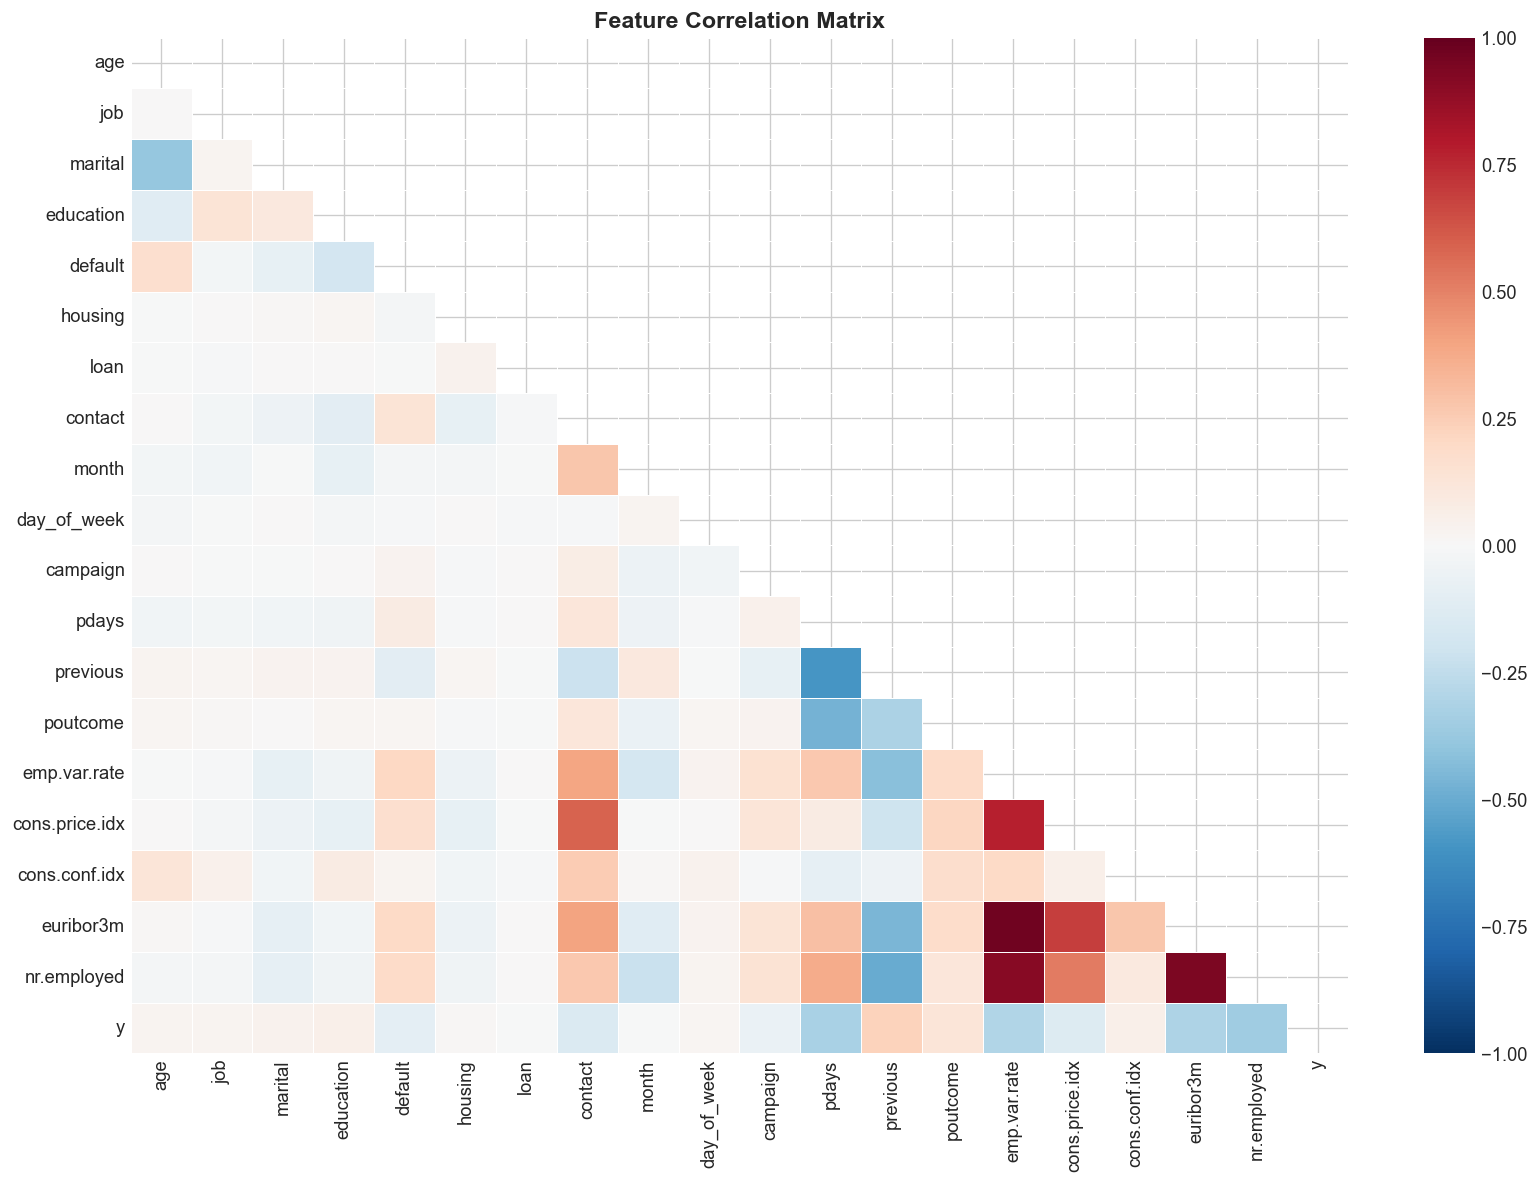

In [10]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Model Tournament (MLflow Tracked)

In [11]:
# Define all 5 contestants
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE,
            class_weight='balanced', C=1.0
        ))
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=8,
        eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.05,
        auto_class_weights='Balanced', random_seed=RANDOM_STATE, verbose=0
    )
}

print(f'✅ {len(models)} contestants ready:')
for name in models:
    print(f'   → {name}')

✅ 5 contestants ready:
   → LogisticRegression
   → RandomForest
   → XGBoost
   → LightGBM
   → CatBoost


In [12]:
# Run the tournament with MLflow tracking
mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('mlops-model-tournament-notebook')

results = {}
run_ids = {}

with mlflow.start_run(run_name='tournament-notebook') as parent:
    mlflow.log_param('n_train', len(X_train))
    mlflow.log_param('n_test', len(X_test))
    mlflow.log_param('n_features', X_train.shape[1])
    mlflow.set_tag('source', 'notebook')

    for name, model in models.items():
        print(f'Training {name}...', end=' ')
        
        with mlflow.start_run(run_name=name, nested=True) as child:
            run_ids[name] = child.info.run_id
            
            # Train
            t0 = time.time()
            model.fit(X_train, y_train)
            train_time = round(time.time() - t0, 2)
            
            # Predict
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]
            
            # Metrics
            metrics = {
                'roc_auc':   round(roc_auc_score(y_test, y_prob), 4),
                'f1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
                'precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
                'recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
                'accuracy':  round(accuracy_score(y_test, y_pred), 4),
                'train_time_seconds': train_time
            }
            results[name] = metrics
            
            mlflow.log_metrics(metrics)
            mlflow.set_tag('model_type', name)
            mlflow.sklearn.log_model(model, name)
            
            print(f'AUC={metrics["roc_auc"]:.4f} | F1={metrics["f1"]:.4f} | {train_time}s')

    # Select champion
    champion = max(results, key=lambda m: results[m]['roc_auc'])
    mlflow.set_tag('champion', champion)
    mlflow.log_metric('champion_auc', results[champion]['roc_auc'])

print(f'\n🏆 CHAMPION: {champion} (AUC={results[champion]["roc_auc"]:.4f})')

2026/06/07 14:17:21 INFO mlflow.tracking.fluent: Experiment with name 'mlops-model-tournament-notebook' does not exist. Creating a new experiment.


Training LogisticRegression... 

2026/06/07 14:17:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 14:17:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


AUC=0.7959 | F1=0.4403 | 0.18s
Training RandomForest... 

2026/06/07 14:17:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 14:17:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

AUC=0.8135 | F1=0.4965 | 2.71s
Training LightGBM... 

2026/06/07 14:17:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 14:17:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


AUC=0.8144 | F1=0.5023 | 3.83s
Training CatBoost... 

2026/06/07 14:18:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 14:18:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


AUC=0.8139 | F1=0.4861 | 3.16s

🏆 CHAMPION: RandomForest (AUC=0.8174)


## 5. Results & Champion Selection

In [13]:
# Leaderboard
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('roc_auc', ascending=False)
results_df.index = [f'{i} 🏆' if i == champion else i for i in results_df.index]

print('=' * 70)
print('🏆 TOURNAMENT LEADERBOARD')
print('=' * 70)
print(results_df[['roc_auc', 'f1', 'precision', 'recall', 'accuracy', 'train_time_seconds']].to_string())
print('=' * 70)

🏆 TOURNAMENT LEADERBOARD
                    roc_auc      f1  precision  recall  accuracy  train_time_seconds
RandomForest 🏆       0.8174  0.5182     0.4368  0.6369    0.8666                2.09
LightGBM             0.8144  0.5023     0.4056  0.6595    0.8528                3.83
CatBoost             0.8139  0.4861     0.3879  0.6509    0.8450                3.16
XGBoost              0.8135  0.4965     0.4009  0.6519    0.8511                2.71
LogisticRegression   0.7959  0.4403     0.3315  0.6552    0.8123                0.18


In [14]:
# Styled leaderboard table
display_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
display_df.style\
    .background_gradient(subset=['roc_auc', 'f1'], cmap='Blues')\
    .format({
        'roc_auc': '{:.4f}', 'f1': '{:.4f}', 'precision': '{:.4f}',
        'recall': '{:.4f}', 'accuracy': '{:.4f}', 'train_time_seconds': '{:.2f}s'
    })\
    .set_caption('Model Tournament Results — UCI Bank Marketing (41,188 rows)')

,roc_auc,f1,precision,recall,accuracy,train_time_seconds
RandomForest,0.8174,0.5182,0.4368,0.6369,0.8666,2.09s
LightGBM,0.8144,0.5023,0.4056,0.6595,0.8528,3.83s
CatBoost,0.8139,0.4861,0.3879,0.6509,0.8450,3.16s
XGBoost,0.8135,0.4965,0.4009,0.6519,0.8511,2.71s
LogisticRegression,0.7959,0.4403,0.3315,0.6552,0.8123,0.18s


## 6. Visualisations

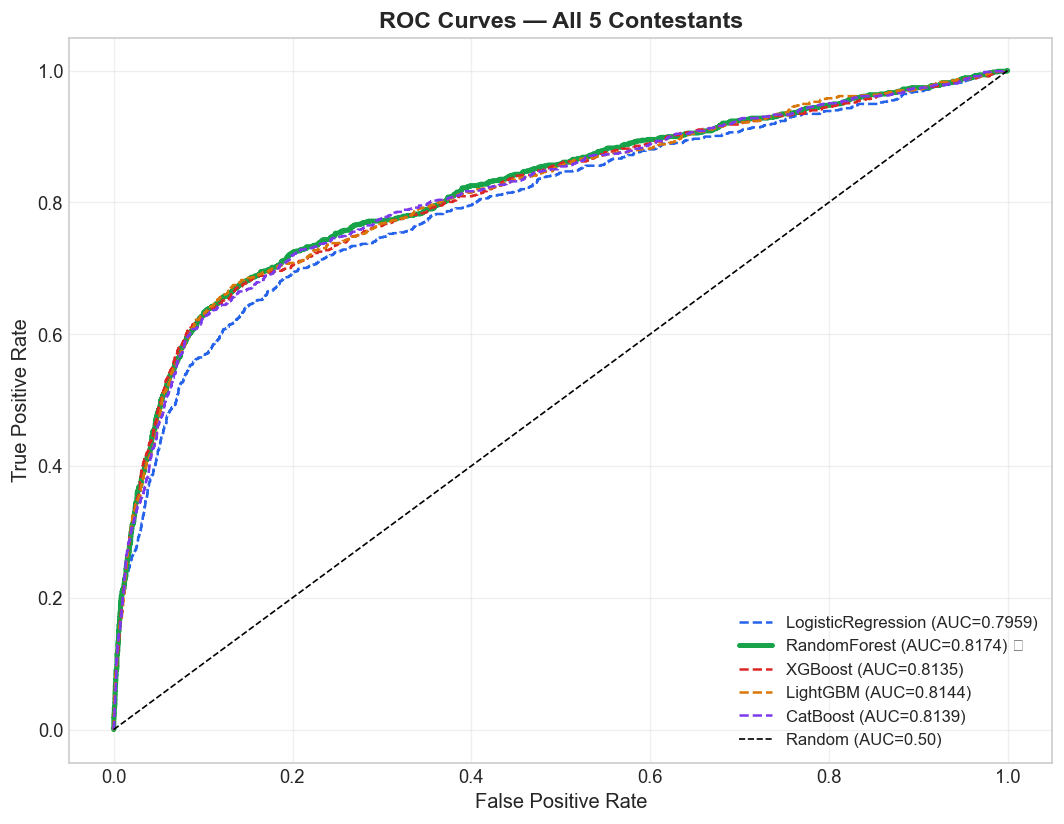

In [15]:
# ROC Curves — all models
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED']

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = results[name]['roc_auc']
    lw = 3 if name == champion else 1.5
    ls = '-' if name == champion else '--'
    label = f'{name} (AUC={auc:.4f})' + (' 🏆' if name == champion else '')
    ax.plot(fpr, tpr, color=color, lw=lw, ls=ls, label=label)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All 5 Contestants', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

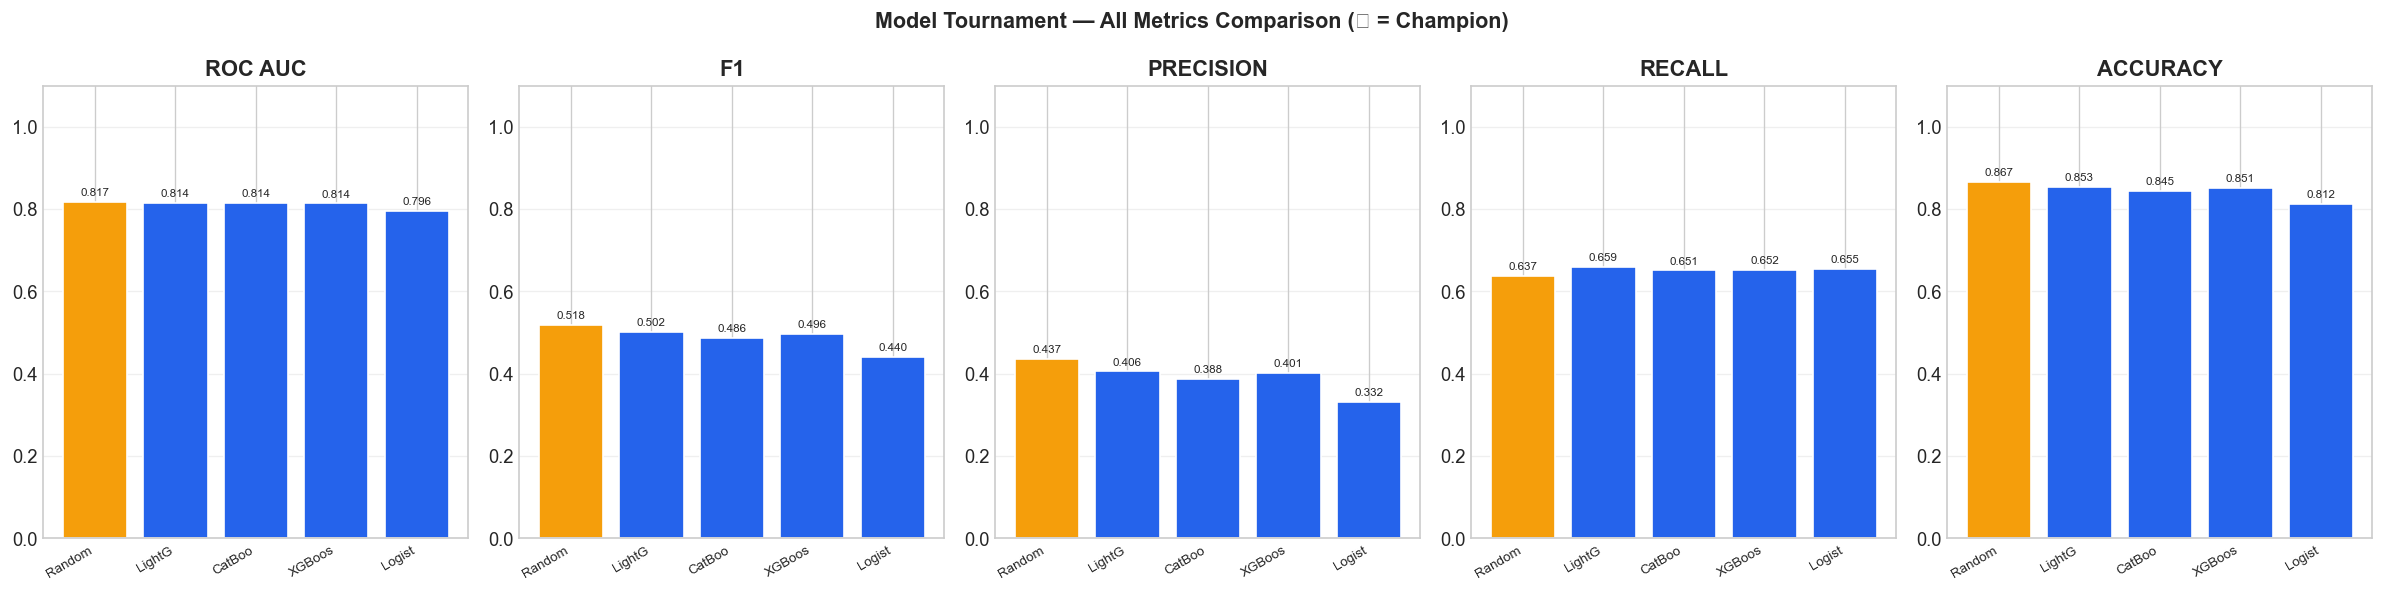

In [16]:
# Metrics comparison bar chart
metrics_to_plot = ['roc_auc', 'f1', 'precision', 'recall', 'accuracy']
plot_df = pd.DataFrame(results).T[metrics_to_plot].sort_values('roc_auc', ascending=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
colors = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED']

for i, metric in enumerate(metrics_to_plot):
    vals = plot_df[metric]
    bar_colors = ['#F59E0B' if idx == champion else '#2563EB' for idx in vals.index]
    bars = axes[i].bar(range(len(vals)), vals.values, color=bar_colors, edgecolor='white')
    axes[i].set_title(metric.upper().replace('_', ' '), fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels([n[:6] for n in vals.index], rotation=30, ha='right', fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Model Tournament — All Metrics Comparison (🏆 = Champion)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

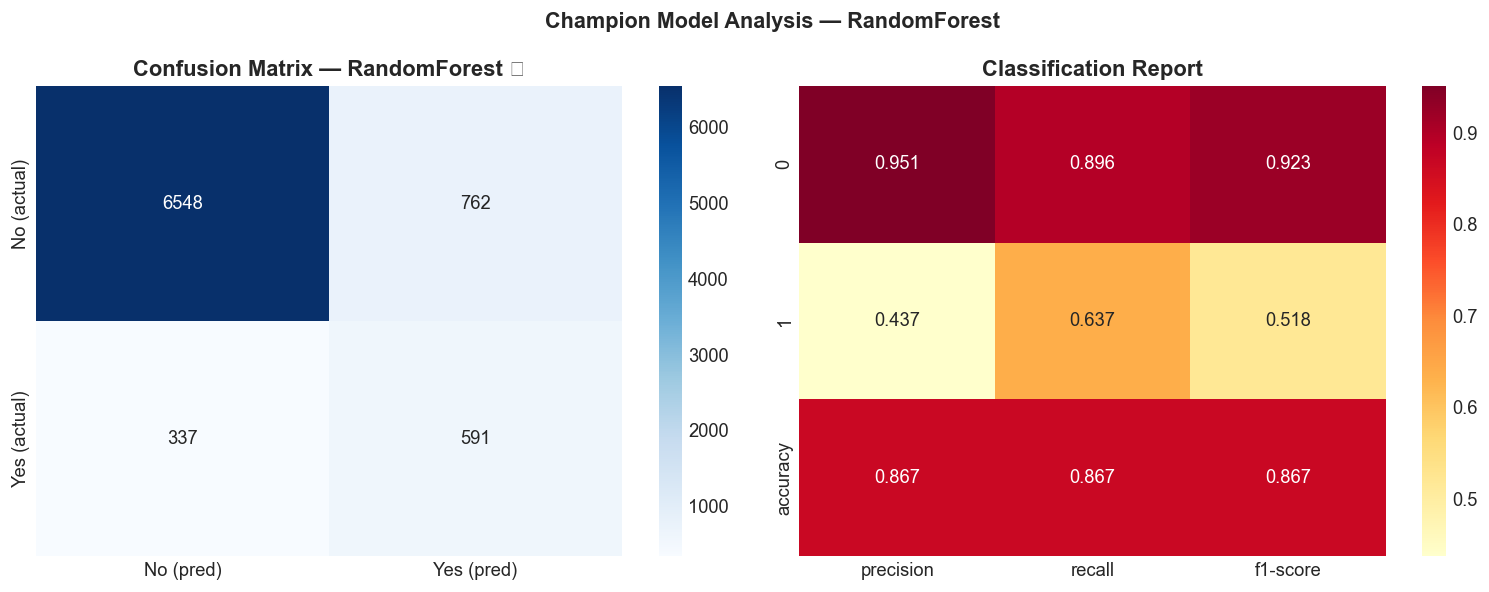


Full Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.90      0.92      7310
         Yes       0.44      0.64      0.52       928

    accuracy                           0.87      8238
   macro avg       0.69      0.77      0.72      8238
weighted avg       0.89      0.87      0.88      8238



In [17]:
# Champion confusion matrix
champion_model = models[champion]
y_pred_champ = champion_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_champ)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No (pred)', 'Yes (pred)'],
            yticklabels=['No (actual)', 'Yes (actual)'])
axes[0].set_title(f'Confusion Matrix — {champion} 🏆', fontweight='bold')

# Classification report heatmap
report = classification_report(y_test, y_pred_champ, output_dict=True)
report_df = pd.DataFrame(report).T.iloc[:3, :3]
sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Classification Report', fontweight='bold')

plt.suptitle(f'Champion Model Analysis — {champion}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nFull Classification Report:')
print(classification_report(y_test, y_pred_champ, target_names=['No', 'Yes']))

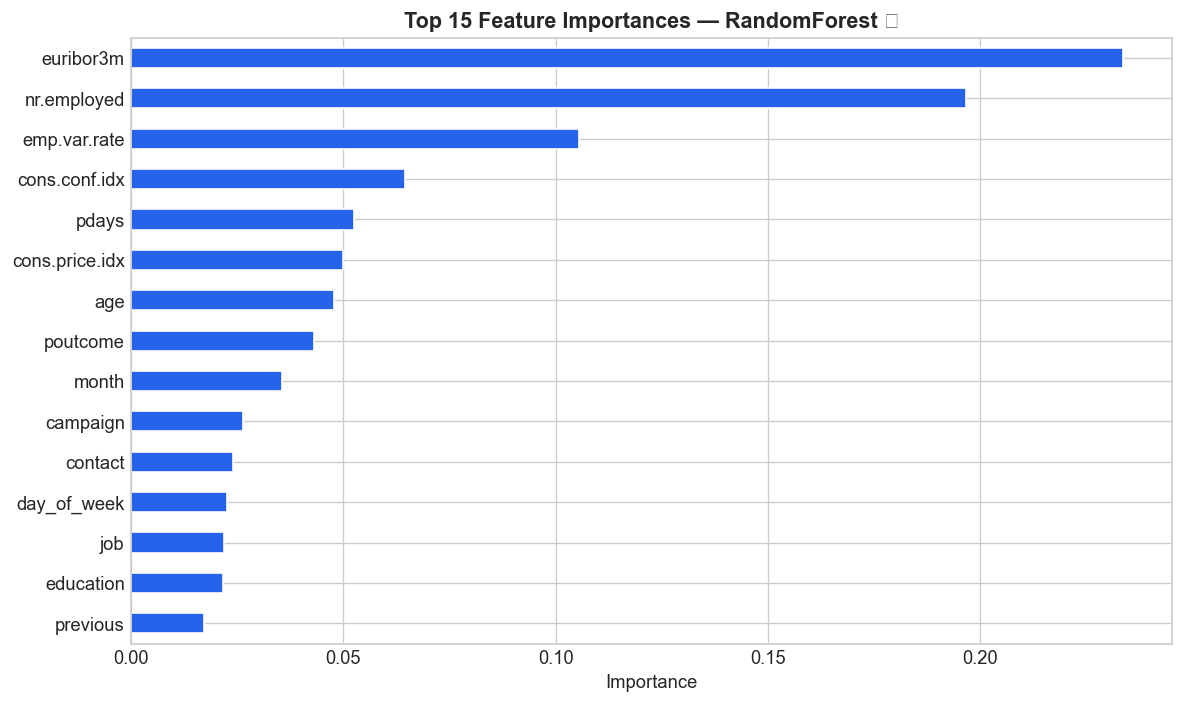

In [18]:
# Feature importance — Champion model
if hasattr(champion_model, 'feature_importances_'):
    importances = champion_model.feature_importances_
elif hasattr(champion_model, 'named_steps'):
    importances = champion_model.named_steps['clf'].coef_[0]
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(np.abs(importances), index=X_train.columns)
    feat_imp = feat_imp.sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp.plot(kind='barh', ax=ax, color='#2563EB', edgecolor='white')
    ax.set_title(f'Top 15 Feature Importances — {champion} 🏆', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 7. MLflow Model Registry

In [19]:
# Register champion to MLflow Model Registry
REGISTRY_NAME = 'BankMarketingChampion'
champion_run_id = run_ids[champion]

try:
    model_uri = f'runs:/{champion_run_id}/{champion}'
    reg = mlflow.register_model(model_uri, REGISTRY_NAME)
    print(f'✅ Registered: {REGISTRY_NAME} v{reg.version}')
    print(f'   Model: {champion}')
    print(f'   AUC:   {results[champion]["roc_auc"]:.4f}')
    print(f'   Run ID: {champion_run_id}')
except Exception as e:
    print(f'Registry note: {e}')

Registered model 'BankMarketingChampion' already exists. Creating a new version of this model...
2026/06/07 14:18:10 WARNING mlflow.tracking._model_registry.fluent: Run with id 43e6b3e64a0f4867a26aea45a91d6741 has no artifacts at artifact path 'RandomForest', registering model based on models:/m-79d0f5198caa4d3da217bb98e847d694 instead


✅ Registered: BankMarketingChampion v3
   Model: RandomForest
   AUC:   0.8174
   Run ID: 43e6b3e64a0f4867a26aea45a91d6741


Created version '3' of model 'BankMarketingChampion'.


In [20]:
# View all registered models
client = mlflow.tracking.MlflowClient()
try:
    models_list = client.search_registered_models()
    print('=== MLFLOW MODEL REGISTRY ===')
    for m in models_list:
        print(f'  Model: {m.name}')
        for v in m.latest_versions:
            print(f'    Version {v.version} | Stage: {v.current_stage} | Run: {v.run_id[:8]}...')
except Exception as e:
    print(f'Registry query note: {e}')

=== MLFLOW MODEL REGISTRY ===
  Model: BankMarketingChampion
    Version 3 | Stage: None | Run: 43e6b3e6...


## 8. Key Takeaways

In [21]:
print('=' * 65)
print('📋 KEY TAKEAWAYS — MLOps Model Tournament')
print('=' * 65)

print(f'''
DATASET
  Real UCI Bank Marketing — 41,188 rows, 19 features
  Class imbalance: 11.3% positive (term deposit subscription)
  duration dropped — leakage feature (unknown pre-call)

RESULTS
  Champion: {champion} (AUC={results[champion]["roc_auc"]:.4f})
  All 4 gradient boosting models cluster: AUC 0.813-0.817
  Meaningful separation needs hyperparameter tuning (Project 4)

MLOPS CONCEPTS DEMONSTRATED
  ✅ Experiment tracking   — MLflow parent/child run structure
  ✅ Model versioning      — MLflow Model Registry
  ✅ Champion/challenger   — automated AUC-based selection
  ✅ CI/CD for ML          — GitHub Actions test→train→gate→promote
  ✅ Leakage discipline    — documented feature removal
  ✅ Class imbalance       — balanced weights across all models

NEXT STEPS
  Project 2: DVC + Scheduled Retraining Pipeline
  Project 4: Optuna hyperparameter tuning (beat AUC 0.82+)
  Project 5: Deploy champion to FastAPI + Docker + Cloud Run
''')
print('=' * 65)
print(f'GitHub: https://github.com/jumma786/mlops-model-tournament')
print('=' * 65)

📋 KEY TAKEAWAYS — MLOps Model Tournament

DATASET
  Real UCI Bank Marketing — 41,188 rows, 19 features
  Class imbalance: 11.3% positive (term deposit subscription)
  duration dropped — leakage feature (unknown pre-call)

RESULTS
  Champion: RandomForest (AUC=0.8174)
  All 4 gradient boosting models cluster: AUC 0.813-0.817
  Meaningful separation needs hyperparameter tuning (Project 4)

MLOPS CONCEPTS DEMONSTRATED
  ✅ Experiment tracking   — MLflow parent/child run structure
  ✅ Model versioning      — MLflow Model Registry
  ✅ Champion/challenger   — automated AUC-based selection
  ✅ CI/CD for ML          — GitHub Actions test→train→gate→promote
  ✅ Leakage discipline    — documented feature removal
  ✅ Class imbalance       — balanced weights across all models

NEXT STEPS
  Project 2: DVC + Scheduled Retraining Pipeline
  Project 4: Optuna hyperparameter tuning (beat AUC 0.82+)
  Project 5: Deploy champion to FastAPI + Docker + Cloud Run

GitHub: https://github.com/jumma786/mlops-mo

---
**Author:** Jumma Mohammad Teli | Data Analyst & ML Engineer | Birmingham, UK  
**LinkedIn:** https://linkedin.com/in/jumma-mohammad  
**GitHub:** https://github.com/jumma786  

*Project 1 of 10 — MLOps Portfolio Series*